# Introdução 

## Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

## Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

## Objetivo 

O objetivo da análise será averiguar a eficiência dos operadores de acordo com as orientações base fornecidas pela companhia para oferecer ao fim uma avaliação confiável para tomada de decisão.

# Setup e Dados

## Ambiente

### Importação bibliotecas

In [252]:
# importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import stats as st 
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import warnings 

### Configurações Globais

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Carregamento de dados

In [3]:
# leitura primeiro dataset
telecom = pd.read_csv('../datasets/telecom_dataset_new.csv')

In [4]:
# leitura segundo dataset
clients = pd.read_csv('../datasets/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

In [5]:
# primeira visualização
telecom.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [6]:
# descoberta informações sobre os dados  
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [7]:
# descoberta características dos dados
telecom.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,53902.00,167295.34,598.88,166377.00,166782.00,167162.00,167819.00,168606.00
operator_id,45730.00,916535.99,21254.12,879896.00,900788.00,913938.00,937708.00,973286.00
calls_count,53902.00,16.45,62.92,1.00,1.00,4.00,12.00,4817.00
call_duration,53902.00,866.68,3731.79,0.00,0.00,38.00,572.00,144395.00
total_call_duration,53902.00,1157.13,4403.47,0.00,47.00,210.00,902.00,166155.00


O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case, encontram-se valores ausentes nas colunas *internal* e *operator_id* e seria mais adequado mudança no tipo de dado em colunas como *date* e *operator_id*.

In [8]:
# primeira visualização
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [9]:
# descoberta informações sobre os dados  
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


In [10]:
# descoberta características dos dados  
clients.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,732.00,167431.93,633.81,166373.00,166900.75,167432.00,167973.00,168606.00


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case, não encontram-se valores ausentes e seria mais adequado mudança no tipo de dado na coluna *date_start*.  

### Valores duplicados

In [11]:
# # descoberta quantidade de registros duplicados dataset clients
clients.duplicated().sum()

np.int64(0)

In [12]:
# descoberta quantidade de registros duplicados dataset telecom
telecom.duplicated().sum()

np.int64(4900)

In [13]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [14]:
# eliminação registros duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

4900 registros (~9% dos dados) foram deletados por se tratarem de duplicatas. Não aparenta possuir um padrão claro de repetição.

### Valores nulos

In [15]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [16]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [17]:
# visualização de registros duplicados
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [18]:
# visualização de registros duplicados
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [19]:
# 
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora de valores nulos na coluna 'operator_id' possuem 'is_missed_call' == True. 

Esse fato pode ser derivado de um erro sistêmico ou chamadas que nem sequer foram atribuídas a um operador (erro sistêmico). 

In [20]:
# exclusão valores nulos
telecom = telecom.dropna()  

Cerca de 7500 registros (~15% dos dados) foram deletados por possível erro sistêmico. 

### Ajuste tipo de dado

In [21]:
# ajuste tipo de dado 'date'
telecom['date'] = pd.to_datetime(telecom['date'])

In [22]:
# ajuste fuso horário
telecom['date'] = telecom['date'].dt.tz_convert('Europe/Lisbon')

In [23]:
# ajuste date_start
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Criação novas colunas

In [24]:
# criação coluna 'waiting_time'
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']

In [25]:
# criação coluna 'month'
telecom['month'] = telecom['date'].dt.month 

In [26]:
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [27]:
# criação coluna 'day'
telecom['day'] = telecom['date'].dt.day

In [85]:
# criação coluna 'week'
telecom['day_of_week'] = telecom['date'].dt.dayofweek

In [29]:
# criação coluna 'is_weekend'
telecom['is_weekend'] = telecom['day_of_week'].isin([5,6]).astype(int)

In [30]:
# criação coluna 'hour'
telecom['hour'] = telecom['date'].dt.hour

In [31]:
print(telecom['month'].nunique())
print(telecom['day'].nunique())
print(telecom['day_of_week'].nunique())
print(telecom['hour'].nunique()) 

4
31
7
2


Não será possível analisar a variação de horas, tratam-se de dados agregados diariamente.

In [32]:
telecom = telecom.drop(columns='hour')

# Análise Exploratória de Dados

### Volume mensal de chamadas

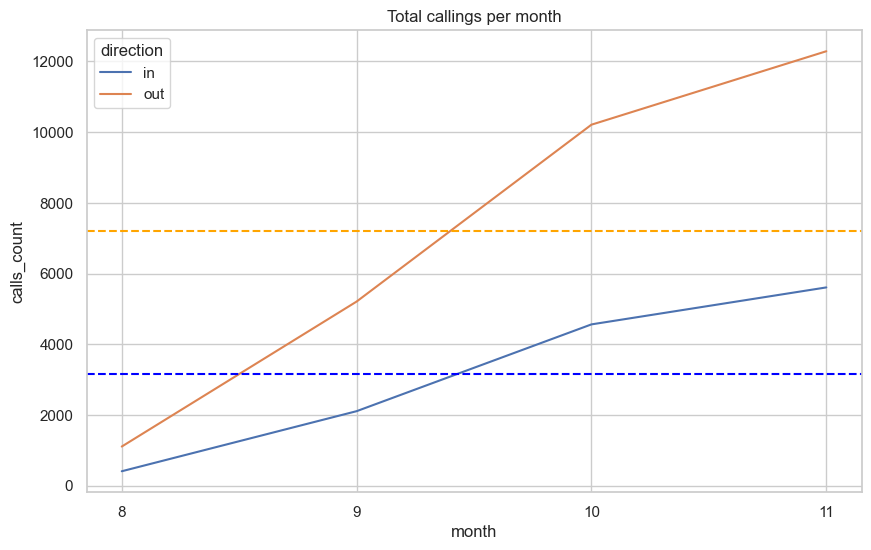

Média mensal geral de chamadas: 10372.75
Média mensal geral de chamadas outound: 7203.25
Média mensal geral de chamadas inbound: 3169.50


In [208]:
# criação de gráfico de linhas
sns.lineplot(data=telecom.groupby(['month', 'direction'])['calls_count'].count().reset_index(), x='month', y='calls_count', hue='direction')
plt.title('Total callings per month')
plt.xticks(telecom['month'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in'].shape[0] / telecom['month'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out'].shape[0] / telecom['month'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média mensal geral de chamadas: {telecom['calls_count'].count() / telecom['month'].nunique():.2f}")
print(f"Média mensal geral de chamadas outound: {telecom[telecom['direction'] == 'out'].shape[0] / telecom['month'].nunique():.2f}")
print(f"Média mensal geral de chamadas inbound: {telecom[telecom['direction'] == 'in'].shape[0] / telecom['month'].nunique():.2f}")

Aumento exponencial do volume de chamadas ao longo do período (~600%).

### Volume semanal de chamadas

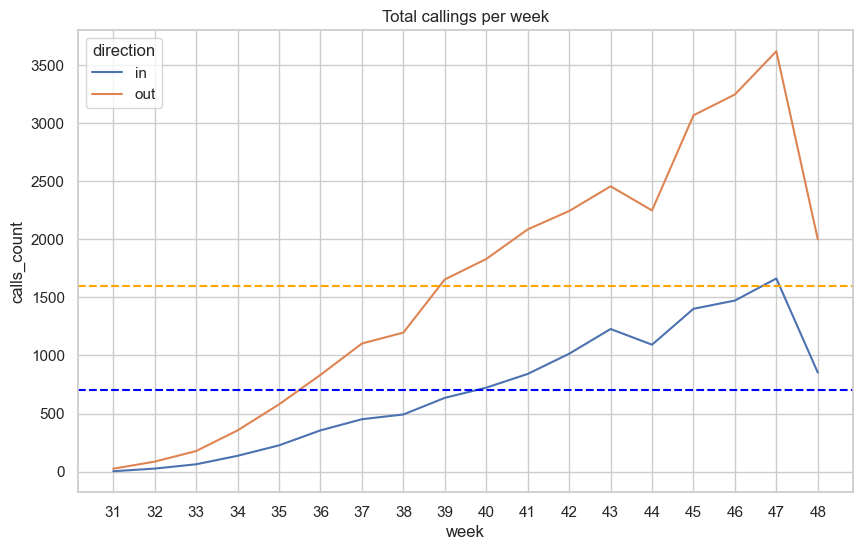

Média semanal de chamadas: 2305.06
Média semanal geral de chamadas outound: 1600.72
Média semanal geral de chamadas inbound: 704.33


In [211]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['calls_count'].count().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Total callings per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in'].shape[0] / telecom['week'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out'].shape[0] / telecom['week'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média semanal de chamadas: {telecom['calls_count'].count() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas outound: {telecom[telecom['direction'] == 'out'].shape[0] / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas inbound: {telecom[telecom['direction'] == 'in'].shape[0] / telecom['week'].nunique():.2f}")

O crescimento do volume de chamadas reafirma o padrão visto dentro do volume mensal, mas com o detalhe de que já nas últimas semanas estava acontecendo um declínio.

### Volume diário de chamadas

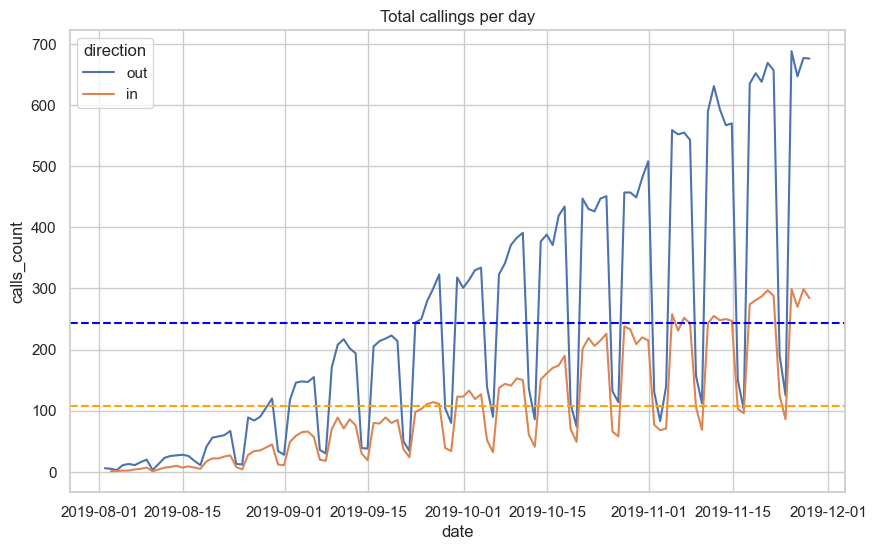

Média diária geral de chamadas: 351.62
Média diária geral de chamadas outound: 244.18
Média diária geral de chamadas inbound: 107.44


In [215]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['date', 'direction'])['calls_count'].count().reset_index(), x='date', y='calls_count', hue='direction')
plt.title('Total callings per day')
plt.axhline(y=(telecom[telecom['direction'] == 'in'].shape[0] / telecom['date'].nunique()), color='orange', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out'].shape[0] / telecom['date'].nunique()), color='blue', linestyle='--')
plt.show()
print(f"Média diária geral de chamadas: {telecom['calls_count'].count() / telecom['date'].nunique():.2f}")
print(f"Média diária geral de chamadas outound: {telecom[telecom['direction'] == 'out'].shape[0] / telecom['date'].nunique():.2f}")
print(f"Média diária geral de chamadas inbound: {telecom[telecom['direction'] == 'in'].shape[0] / telecom['date'].nunique():.2f}")

Visualização do mesmo padrão visto anteriormente, as oscilações devem-se referir aos dias de menor volume de chamadas (fins de semana).

### Proporção de chamadas por dia da semana

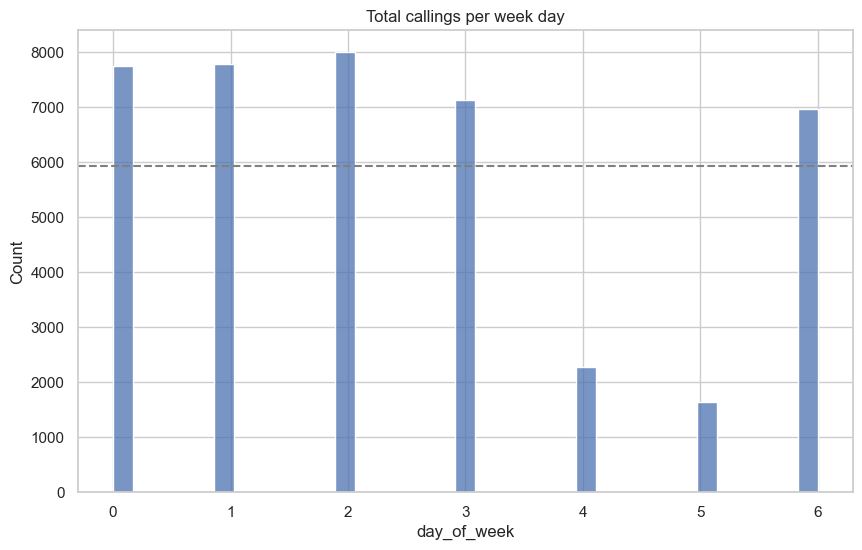

Porcentagem de chamadas no dia 6: 16.79%
Porcentagem de chamadas no dia 0: 18.66%
Porcentagem de chamadas no dia 1: 18.73%
Porcentagem de chamadas no dia 2: 19.27%
Porcentagem de chamadas no dia 3: 17.15%
Porcentagem de chamadas no dia 4: 5.46%
Porcentagem de chamadas no dia 5: 3.94%


In [217]:
# criação histplot
sns.histplot(telecom['day_of_week'])
plt.title('Total callings per week day')
plt.axhline(y=(telecom['calls_count'].count() / telecom['day_of_week'].nunique()), color='gray', linestyle='--')
plt.show()
for x in telecom['day_of_week'].unique():
    print(f"Porcentagem de chamadas no dia {x}: {(telecom[telecom['day_of_week'] == x].shape[0] / telecom.shape[0]) * 100:.2f}%")

Sexta-feira e sábado são os dias com menores volume de chamadas.

Finais de semana representam cerca de 20% das chamadas.

### Proporção de chamadas inbound e outbound

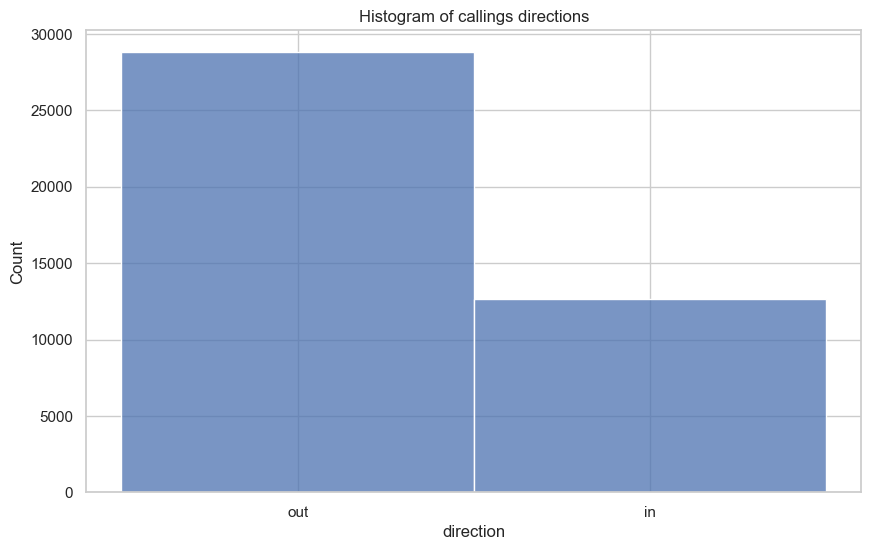

Porcentagem de chamadas outbound: 69.44%
Porcentagem de chamadas inbound: 30.56%


In [146]:
# criação histograma
sns.histplot(telecom['direction'])
plt.title('Histogram of callings directions')
plt.xticks(telecom['direction'].unique())
plt.show()
print(f"Porcentagem de chamadas outbound: {(telecom[telecom['direction'] == 'out'].shape[0] / telecom.shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound: {(telecom[telecom['direction'] == 'in'].shape[0] / telecom.shape[0]) * 100:.2f}%")

Chamadas outbound representam a maioria dos dados (aproximadamente 70% x 30%).

### Proporção de chamadas internas e externas

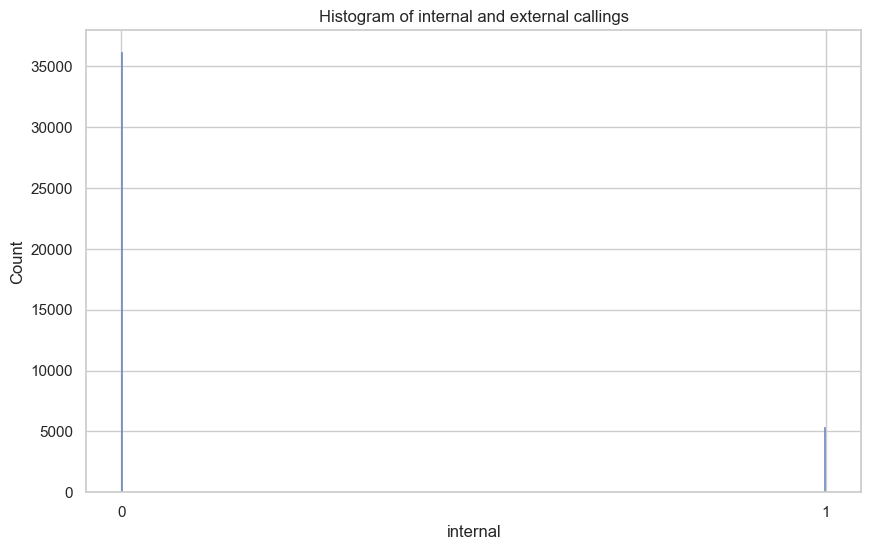

Porcentagem de chamadas externas: 87.15%
Porcentagem de chamadas internas: 12.85%


In [ ]:
# criação histograma
sns.histplot(telecom['internal'])
plt.title('Histogram of internal callings')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas externas: {(telecom[telecom['internal'] == False].shape[0] / telecom.shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas internas: {(telecom[telecom['internal'] == True].shape[0] / telecom.shape[0]) * 100:.2f}%")

As proporções de chamadas internas x externas são desbalanceadas (87,15% x 12,85%).

### Variação semanal de chamadas perdidas

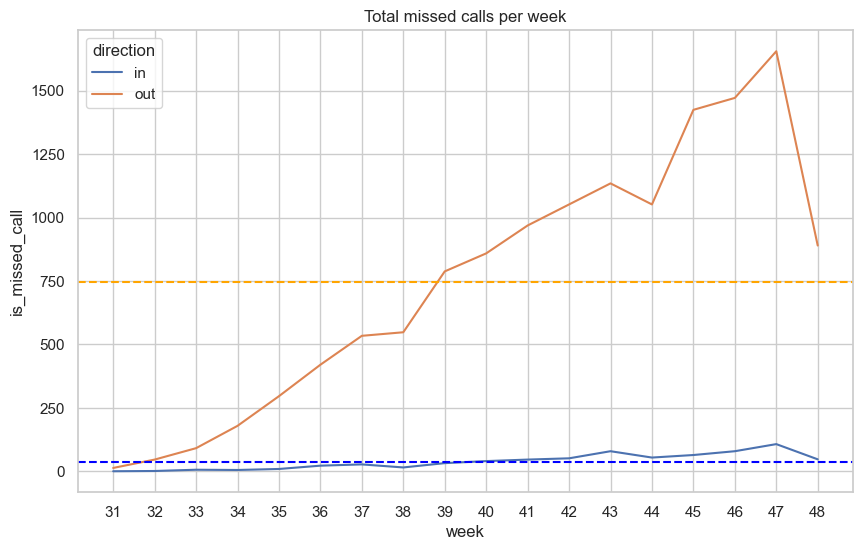

Média semanal geral de chamadas outbound perdidas: 745.83
Média semanal geral de chamadas inbound perdidas: 38.00


In [222]:
#criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['is_missed_call'].sum().reset_index(), x='week', y='is_missed_call', hue='direction')
plt.title('Total missed calls per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)].shape[0] / telecom['week'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)].shape[0] / telecom['week'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média semanal geral de chamadas outbound perdidas: {telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)].shape[0] / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas inbound perdidas: {telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)].shape[0] / telecom['week'].nunique():.2f}")

O crescimento do volume de chamadas inbound perdidas segue o fluxo linear e esperado, enquanto o fluxo de chamadas outbound perdidas segue um fluxo exponencial.

### Proporção de chamadas inbound perdidas 

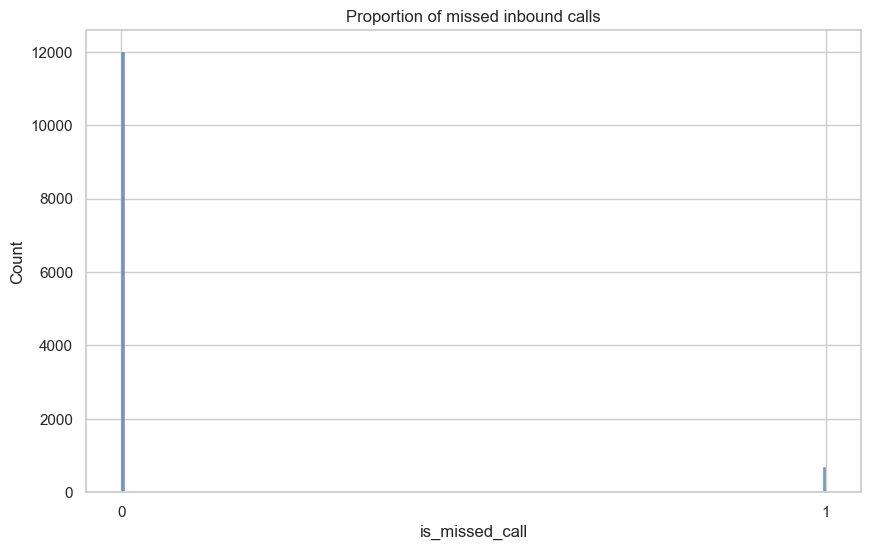

Porcentagem de chamadas inbound atendidas: 94.60%
Porcentagem de chamadas inbound perdidas: 5.40%


In [225]:
sns.histplot(telecom[telecom['direction'] == 'in']['is_missed_call'])
plt.title('Proportion of missed inbound calls')
plt.xticks([0,1])
plt.show()
print(f"Porcentagem de chamadas inbound atendidas: {(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == False)].shape[0] / telecom[(telecom['direction'] == 'in')].shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound perdidas: {(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)].shape[0] / telecom[(telecom['direction'] == 'in')].shape[0]) * 100:.2f}%")

A proporção de chamadas inbound perdidas são a minoria (~5% x ~95%).

### Proporção de chamadas outbound perdidas 

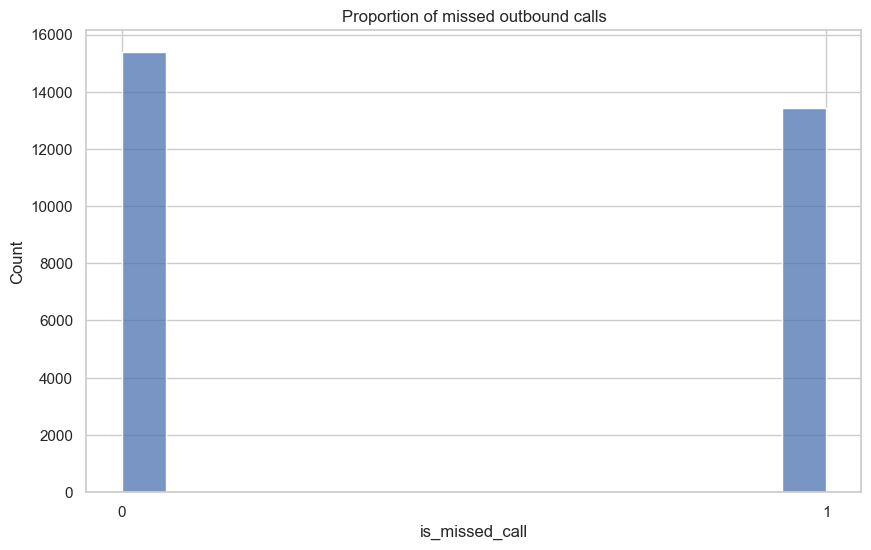

Porcentagem de chamadas inbound atendidas: 53.41%
Porcentagem de chamadas inbound perdidas: 46.59%


In [224]:
# criação histograma
sns.histplot(telecom[telecom['direction'] == 'out']['is_missed_call'])
plt.title('Proportion of missed outbound calls')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas inbound atendidas: {(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == False)].shape[0] / telecom[(telecom['direction'] == 'out')].shape[0]) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound perdidas: {(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)].shape[0] / telecom[(telecom['direction'] == 'out')].shape[0]) * 100:.2f}%")


A proporção de chamadas outbound perdidas são quase a metade (~47% x ~53%).

### Distribuição tempo de espera

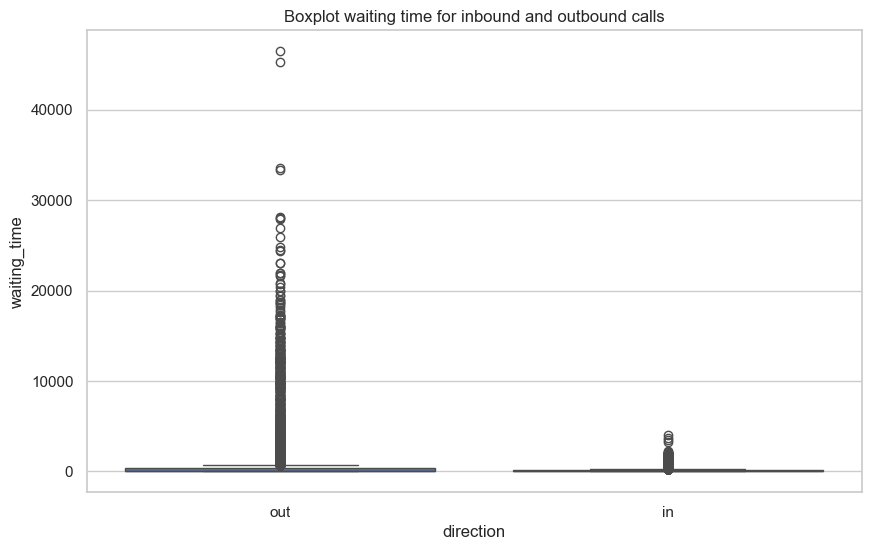

In [292]:
# criação boxplot
sns.boxplot(data=telecom, x='direction', y='waiting_time')
plt.title('Boxplot waiting time for inbound and outbound calls')
plt.show()

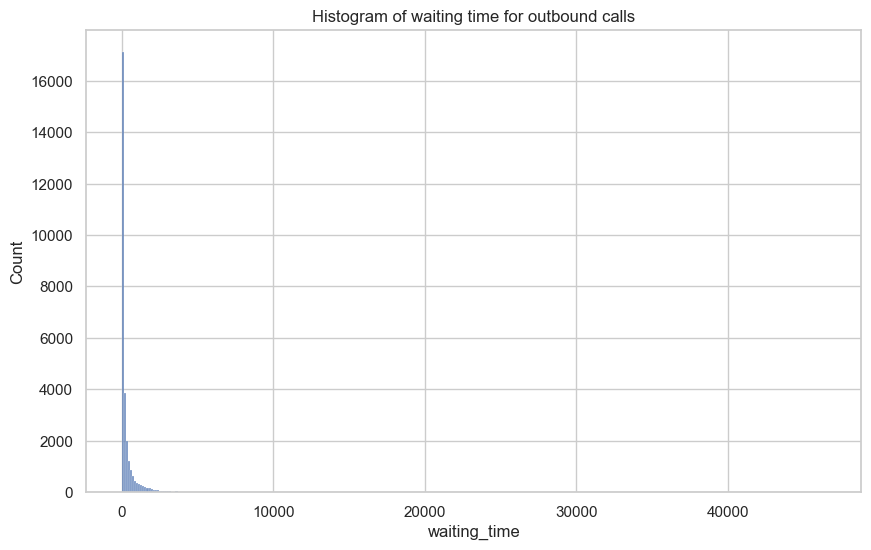

In [293]:
# criação histograma para tempo de espera em chamadas outbound
sns.histplot(data=telecom[telecom['direction'] == 'out']['waiting_time'])
plt.title('Histogram of waiting time for outbound calls')
plt.show()

Presença massiva de outliers para chamadas outbound.

### Variação mediana do tempo de espera semanal

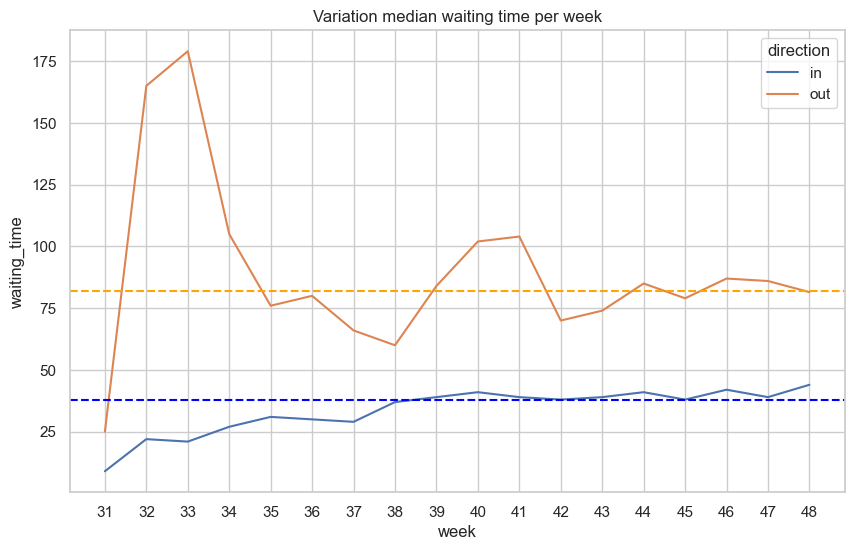

Mediana geral semanal de chamadas outbound: 82.0
Mediana geral semanal de chamadas inbound: 38.0


In [204]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['waiting_time'].median().reset_index(), x='week', y='waiting_time', hue='direction')
plt.title('Variation median waiting time per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=telecom[telecom['direction'] == 'in']['waiting_time'].median(), color='blue', linestyle='--')
plt.axhline(y=telecom[telecom['direction'] == 'out']['waiting_time'].median(), color='orange', linestyle='--')
plt.show()
print(f"Mediana geral semanal de chamadas outbound: {telecom[telecom['direction'] == 'out']['waiting_time'].median()}")
print(f"Mediana geral semanal de chamadas inbound: {telecom[telecom['direction'] == 'in']['waiting_time'].median()}")

A mediana do tempo de espera para chamadas inbound cresceu ao longo do período, enquanto para chamadas outbound teve um pico na primeira semana, seguida por grande queda e seguinte estabilização.

### Variação de operadores trabalhando por semana

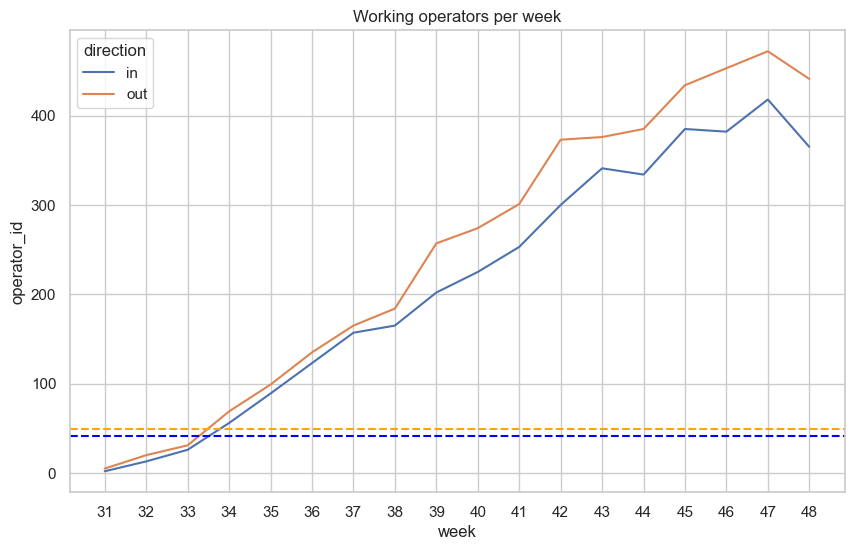

Média semanal geral de operadores trabalhando: 60.67
Média semanal geral de operadores outbound trabalhando: 49.00
Média semanal geral de operadores inbound trabalhando: 41.89


In [232]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['operator_id'].nunique().reset_index(), x='week', y='operator_id', hue='direction')
plt.title('Working operators per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in']['operator_id'].nunique() / telecom['week'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out']['operator_id'].nunique() / telecom['week'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média semanal geral de operadores trabalhando: {telecom['operator_id'].nunique() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de operadores outbound trabalhando: {telecom[telecom['direction'] == 'out']['operator_id'].nunique() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de operadores inbound trabalhando: {telecom[telecom['direction'] == 'in']['operator_id'].nunique() / telecom['week'].nunique():.2f}")

Durante todo o período, houve aumento do número de operadores à postos tanto para inbound tanto para outbound.

### Observações gerais

* Pode-se ser notado que houve um crescimento exponencial no volume de chamadas dentro do período analisado (Agosto a Novembro), tanto para inbound e outbound - o aumento do número de operadores à postos seguiu o mesmo ritmo.
* Chamadas outbound representam maioria, cerca de 60%.
* O crescimento das chamadas perdidas foi exponencial apenas para chamadas outbound, enquanto inbound linear.
* Enquanto cerca de 95% das chamadas inbound não são perdidas, para chamadas outbound isso representa cerca de 54%. 

# Cálculo KPIs e Identificação de Ineficiência 

### Criação tabela agregada

In [294]:
# criação tabela agregada
telecom_agg = telecom.groupby(['user_id', 'operator_id', 'direction']).agg({'calls_count': 'count', 'is_missed_call': 'sum', 'waiting_time': 'median'}).reset_index().rename(columns={'waiting_time': 'median_waiting_time'})

In [295]:
telecom_agg

,user_id,operator_id,direction,calls_count,is_missed_call,median_waiting_time
0,166377,880020.00,in,7,0,7.00
1,166377,880020.00,out,13,6,8.00
2,166377,880022.00,in,8,0,16.00
3,166377,880022.00,out,62,29,12.50
4,166377,880026.00,in,18,0,6.50
...,...,...,...,...,...,...
1631,168601,952916.00,in,1,0,25.00
1632,168601,952916.00,out,4,1,32.50
1633,168603,959118.00,out,6,2,41.00
1634,168606,957922.00,in,2,1,13.00


###  Ratio chamadas inbound perdidas > 5% da equipe

In [296]:
# criação coluna 'missed_rate' 
telecom_agg['missed_rate'] = telecom_agg['is_missed_call'] / telecom_agg['calls_count']
telecom_agg

,user_id,operator_id,direction,calls_count,is_missed_call,median_waiting_time,missed_rate
0,166377,880020.00,in,7,0,7.00,0.00
1,166377,880020.00,out,13,6,8.00,0.46
2,166377,880022.00,in,8,0,16.00,0.00
3,166377,880022.00,out,62,29,12.50,0.47
4,166377,880026.00,in,18,0,6.50,0.00
...,...,...,...,...,...,...,...
1631,168601,952916.00,in,1,0,25.00,0.00
1632,168601,952916.00,out,4,1,32.50,0.25
1633,168603,959118.00,out,6,2,41.00,0.33
1634,168606,957922.00,in,2,1,13.00,0.50


In [ ]:
# os 'operator_id' com ratio acima do percentil 75 da equipe serão adicionados à variável 'highers_missed_rate'
highers_missed_rate = telecom_agg[telecom_agg['direction'] == 'in']

### Mediana tempo de espera > 60s da equipe

In [ ]:
# os *'operator_id'* com períodos de espera acima do percentil 75 da equipe serão adicionados à variável *'highers_waiting_time'*

### Chamadas outbound < 25

In [ ]:
# os *'operator_id'* com número de chamadas abaixo do percentil 25 da equipe serão adicionados à variável *'lowers_outbound_calls'*

## Testes Estatísticos

### Alta taxa de chamadas inbound perdidas  

In [ ]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_missed_rate(telecom, min_calls=30, alpha=0.05, min_lift=0.05):
    # filtro inbound 
    data = telecom[telecom['direction'] == 'in'].copy()
    results = []

    # criação de ciclo por usuário
    for user in data['user_id'].unique():
        # filtro operadores com volume mínimo
        user_data = data[data['user_id'] == user]
        counts = user_data['operator_id'].value_counts()
        valid_operators = counts[counts >= min_calls].index
        user_data = user_data[user_data['operator_id'].isin(valid_operators)]
        operators = user_data['operator_id'].unique()

        # criação de ciclo por operador
        for op in operators:
            # segregação total chamadas e total chamadas perdidas operador e dados equipe sem operador
            op_data = user_data[user_data['operator_id'] == op]
            team_data = user_data[user_data['operator_id'] != op]
            operator_calls = op_data.shape[0]
            operator_missed = op_data['is_missed_call'].sum()
            team_calls = team_data.shape[0]
            team_missed = team_data['is_missed_call'].sum()

            # validação
            if operator_calls == 0 or team_calls == 0:
                continue

            # aplicação Two-proportion z-test
            stat, p_value = proportions_ztest([operator_missed, team_missed],[operator_calls, team_calls])
            operator_rate = operator_missed / operator_calls
            team_rate = team_missed / team_calls
            lift = operator_rate - team_rate
            
            # decisão baseada em signifcância e intensidade
            fail = (p_value < alpha) and (lift > min_lift)
            results.append({
                'user_id': user,
                'operator_id': op,
                'operator_calls': operator_calls,
                'operator_missed_rate': operator_rate,
                'team_missed_rate': team_rate,
                'lift': lift,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    # organização final
    df = df.sort_values(by=['fail', 'lift'], ascending=[False, False])

    return df

In [278]:
# aplicação função
results_missed_rate = test_missed_rate(telecom)

In [ ]:
# operadores que fallharam no teste estatístico 
results_missed_rate[results_missed_rate['fail'] == True]

,user_id,operator_id,operator_calls,operator_missed_rate,team_missed_rate,lift,p_value,fail
45,167071,913942.00,85,0.33,0.17,0.16,0.02,True
55,167264,919554.00,75,0.15,0.02,0.13,0.01,True
84,168187,937956.00,59,0.14,0.05,0.09,0.00,True
100,168187,948286.00,37,0.14,0.05,0.09,0.02,True
33,166983,901880.00,106,0.09,0.01,0.08,0.00,True


### Alto índice de períodos de espera

In [ ]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_waiting_time(telecom, min_calls=30, min_samples=10, alpha=0.05, min_diff=90):
    # filtro inbound 
    data = telecom[telecom['direction'] == 'in'].copy()
    results = []

    # criação de ciclo por usuário
    for user in data['user_id'].unique():
        # filtro operadores com volume mínimo
        user_data = data[data['user_id'] == user]
        counts = user_data['operator_id'].value_counts()
        valid_operators = counts[counts >= min_calls].index
        user_data = user_data[user_data['operator_id'].isin(valid_operators)]
        operators = user_data['operator_id'].unique()

        # criação de ciclo por operadores 
        for op in operators:
            # distribuição tempo de espera operador e dados equipe sem operador
            op_data = user_data[user_data['operator_id'] == op]
            team_data = user_data[user_data['operator_id'] != op]
            operator_waiting = op_data['waiting_time']
            team_waiting = team_data['waiting_time']

            # validação 
            if len(operator_waiting) < min_samples or len(team_waiting) < min_samples:
                continue

            # aplicação de teste estatístico Mann Whiteney
            stat, p_value = mannwhitneyu(operator_waiting,team_waiting)
            operator_median = operator_waiting.median()
            team_median = team_waiting.median()
            diff = operator_median - team_median

            # decisão baseada em signifcância e intensidade
            fail = (p_value < alpha) and (diff > min_diff)
            results.append({
                'user_id': user,
                'operator_id': op,
                'operator_calls': len(operator_waiting),
                'operator_median_waiting': operator_median,
                'team_median_waiting': team_median,
                'diff_median': diff,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    df = df.sort_values(by=['fail', 'diff_median'], ascending=[False, False])

    return df

In [414]:
results_waiting_time = test_waiting_time(telecom)

In [415]:
results_waiting_time[results_waiting_time['fail'] == True]

,user_id,operator_id,operator_calls,operator_median_waiting,team_median_waiting,diff_median,p_value,fail
63,167521,919794.00,32,953.00,364.00,589.00,0.00,True
61,167521,919790.00,59,951.00,372.00,579.00,0.00,True
68,167650,921318.00,51,620.00,217.00,403.00,0.00,True
46,167071,913938.00,77,531.00,253.00,278.00,0.01,True
69,167650,931458.00,50,545.50,268.50,277.00,0.04,True
29,166916,906406.00,45,390.00,132.00,258.00,0.00,True
26,166916,906404.00,43,314.00,138.00,176.00,0.00,True
10,166541,908958.00,93,260.00,143.00,117.00,0.00,True
66,167532,917852.00,47,148.00,46.50,101.50,0.00,True


### Volume baixo de chamadas outbound

In [ ]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_outbound_calls(telecom, min_weeks=7, alpha=0.05, min_diff=50):
    # filtro outbound 
    data = telecom[telecom['direction'] == 'out'].copy()
    results = []

    # ciclo por cliente
    for user in data['user_id'].unique():
        user_data = data[data['user_id'] == user]
        # agregação por semana
        weekly_calls = user_data.groupby(['operator_id', 'week'])['calls_count'].sum().reset_index()
        operators = weekly_calls['operator_id'].unique()

        # ciclo por operador
        for op in operators:
            op_data = weekly_calls[weekly_calls['operator_id'] == op]
            team_data = weekly_calls[weekly_calls['operator_id'] != op]
            operator_outbound = op_data['calls_count']
            team_outbound = team_data['calls_count']

            # validação 
            if len(operator_outbound) < min_weeks or len(team_outbound) < min_weeks:
                continue

            # aplicação teste estatístico
            stat, p_value = mannwhitneyu(operator_outbound,team_outbound)
            operator_median = operator_outbound.median()
            team_median = team_outbound.median()
            diff = operator_median - team_median  

            # decisão baseada em signifcância e intensidade
            fail = (p_value < alpha) and (diff < -min_diff)

            results.append({
                'user_id': user,
                'operator_id': op,
                'weeks_observed': len(operator_outbound),
                'operator_median_weekly_outbound': operator_median,
                'team_median_weekly_outbound': team_median,
                'diff_median': diff,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    df = df.sort_values(by=['fail', 'diff_median'], ascending=[False, True])

    return df

In [417]:
results_outbound_calls = test_outbound_calls(telecom)

In [418]:
results_outbound_calls[results_outbound_calls['fail']== True]

,user_id,operator_id,weeks_observed,operator_median_weekly_outbound,team_median_weekly_outbound,diff_median,p_value,fail
160,167827,929424.00,9,68.00,1766.00,-1698.00,0.01,True
8,166406,879896.00,16,11.50,333.00,-321.50,0.00,True
155,167650,921306.00,10,53.50,222.00,-168.50,0.00,True
84,167035,923528.00,10,38.50,203.00,-164.50,0.01,True
23,166511,891416.00,14,52.00,184.00,-132.00,0.00,True
0,166377,880022.00,14,6.50,131.50,-125.00,0.00,True
56,166782,899250.00,14,96.00,174.00,-78.00,0.01,True
104,167150,905570.00,12,5.00,83.00,-78.00,0.00,True
105,167150,905574.00,13,24.00,83.00,-59.00,0.02,True
28,166536,900194.00,10,1.50,53.00,-51.50,0.00,True


# Conclusão e Recomendações de Negócio